# Efficiency calculation using the Cerenkov TDCR model

## install a stable version of TDCRPy

In [1]:
pip install TDCRPy==2.19.0

Note: you may need to restart the kernel to use updated packages.


## Import the module

In [2]:
import tdcrpy as td
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

## Enter the input parameters

In [3]:
Rad = "P-32"                   # radionuclides
lambda_range = (300,650)        # range of wavelenght detected by the PMTs
alpha=(1,1,1)          # Anisotropy coefficients

### Efficiency as a function of the free parameter

In [4]:
mode = "eff"                # ask for efficiency calculation
L=np.logspace(-3,2,num=100) # free parameter in keV-1 (photoelectron yield) 

effS, effD, effT = [],[], []
for l in tqdm(L, desc="free parameters ", unit=" iterations"):
  result1 = td.TDCR_model_lib.modelCerenkov(l,0,0,0,0,Rad,mode,lambda_range=lambda_range, alpha=alpha)
  effS.append(result1[0])
  effD.append(result1[1])
  effT.append(result1[2])

free parameters : 100%|██████████| 100/100 [00:00<00:00, 377.71 iterations/s]


### plot of the results

Text(0, 0.5, '$\\epsilon_{D}$')

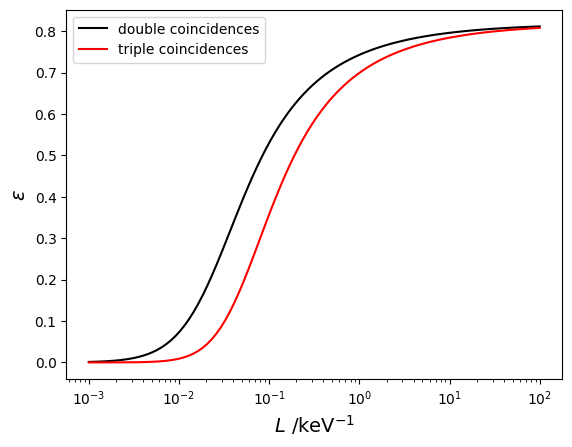

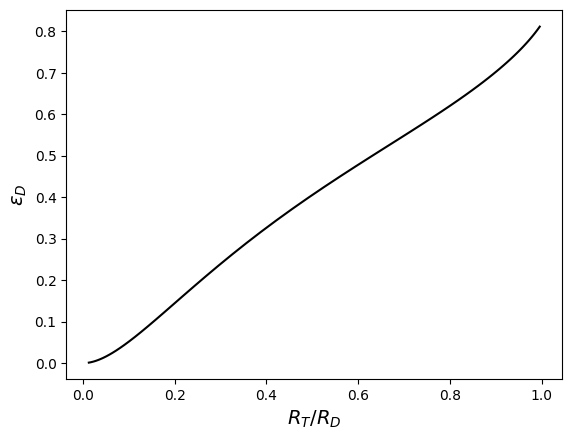

In [5]:
# convert list in array
effS=np.asarray(effS); effT=np.asarray(effT); effD=np.asarray(effD)
# calculate the TDCR parameter
tdcr=effT/effD

plt.figure("efficiency vs free parameter")
plt.clf()
plt.plot(L,effD,"-k",label="double coincidences")
plt.plot(L,effT,"-r",label="triple coincidences")
plt.xscale('log')
plt.xlabel(r'$L$ /keV$^{-1}$', fontsize=14)
plt.ylabel(r'$\epsilon$', fontsize=14)
plt.legend()

plt.figure("efficiency vs TDCR")
plt.clf()
plt.plot(tdcr,effD,"-k")
#plt.xscale('log')
plt.xlabel(r'$R_T/R_D$', fontsize=14)
plt.ylabel(r'$\epsilon_{D}$', fontsize=14)

### Efficiency given the measured TDCR parameters

In [6]:
TD = 712.1275622280198/1019.8810227086548   # TDCR parameter
TAB = 712.1275622280198/813.5823            # TDCR parameter T/AB
TBC = 712.1275622280198/819.3669            # TDCR parameter T/BC
TAC = 712.1275622280198/811.3692            # TDCR parameter T/AC
minL = 0.01                                 # minimum light yield (keV-1)
maxL = 20                                   # maximum light yield (keV-1)

In [7]:


print(f"\nResults using a global parameter")
result2 = td.TDCRPy.effA(TD, Rad, 0, 0, 0, Lbounds=[minL, maxL], cerenkov=True)
print(f"Global free parameter: {result2[0]}")
print(f"Efficiency of single events: {result2[2]}")
print(f"Efficiency of double coincidence events: {result2[3]}")
print(f"Efficiency of triple coincidence events: {result2[4]}\n")

print(f"\nResults using 3 free parameters")
result3 = td.TDCRPy.effA([TD, TAB, TBC, TAC], Rad, 0, 0, 0, Lbounds=[minL, maxL], cerenkov=True)
print(f"Global free parameter: {result3[0]}")
print(f"Free parameter PMT A: {result3[1][0]}")
print(f"Free parameter PMT B: {result3[1][1]}")
print(f"Free parameter PMT C: {result3[1][2]}")
print(f"Efficiency of single events: {result3[2]}")
print(f"Efficiency of double coincidence events: {result3[3]}")
print(f"Efficiency of triple coincidence events: {result3[4]}")


Results using a global parameter
global free parameter = 0.11062502342221396 keV-1
Global free parameter: 0.11062502342221396
Efficiency of single events: 0.6689287047404344
Efficiency of double coincidence events: 0.5473921017599364
Efficiency of triple coincidence events: 0.38221530159720907


Results using 3 free parameters
global free parameter = 0.11062502342221396 keV-1
free parameters = [0.10829283 0.11257366 0.11116122] keV-1
Global free parameter: 0.11062502342221396
Free parameter PMT A: 0.10829283162053323
Free parameter PMT B: 0.11257365773282882
Free parameter PMT C: 0.111161219460448
Efficiency of single events: 0.6689691225696343
Efficiency of double coincidence events: 0.5474493605839013
Efficiency of triple coincidence events: 0.38225123533153116
